In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

from xgboost import XGBClassifier

In [3]:
df = pd.read_csv('../data/Bank Customer Churn Prediction.csv')

In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

print("\nHead:")
print(df.head())

#DATA TYPES
print("\nData Types:")
print(df.dtypes)

#MISSING VALUES
print("\nMissing Values:")
print(df.isnull().sum())

#DUPLICATES
print("\nDuplicate Rows:", df.duplicated().sum())

#BASIC STATS (NUMERIC)
print("\nSummary Stats:")
print(df.describe())

#TARGET DISTRIBUTION
print("\nChurn Distribution (counts):")
print(df['churn'].value_counts())
print("\nChurn Distribution (proportions):")
print(df['churn'].value_counts(normalize=True))

#DROP IRRELEVANT COLUMNS
df = df.drop(columns=['customer_id'])

# CHECK CATEGORICAL VALUES
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

In [5]:
# DEFINING FEATURES and TARGET
X = df.drop(columns=['churn'])
y = df['churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

# IDENTIFY COLUMN TYPES
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)



# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)



# CHECK TARGET DISTRIBUTION AFTER SPLIT
print("\nTrain churn distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest churn distribution:")
print(y_test.value_counts(normalize=True))

X shape: (10000, 10)
y shape: (10000,)

Categorical columns: ['country', 'gender']
Numeric columns: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']

Train shape: (8000, 10)
Test shape: (2000, 10)

Train churn distribution:
churn
0    0.79625
1    0.20375
Name: proportion, dtype: float64

Test churn distribution:
churn
0    0.7965
1    0.2035
Name: proportion, dtype: float64


In [6]:
# PREPROCESSING PIPELINE
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)




In [7]:
# TRAIN MODELS

logistic_model = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

random_forest_model = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])

xgboost_model = Pipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        eval_metric='logloss'
    ))
])

models = {
    'Logistic Regression': logistic_model,
    'Random Forest': random_forest_model,
    'XGBoost': xgboost_model
}

for name, model_obj in models.items():
    model_obj.fit(X_train, y_train)
    print(f"{name} trained.")

Logistic Regression trained.
Random Forest trained.
XGBoost trained.


In [8]:
# EVALUATION FUNCTIONS

def precision_at_top_percent(y_true, y_prob, percent=0.20):
    results = pd.DataFrame({
        'y_true': y_true,
        'y_prob': y_prob
    }).sort_values(by='y_prob', ascending=False)
    
    cutoff = int(percent * len(results))
    top_results = results.head(cutoff)
    
    return top_results['y_true'].mean()


def lift_at_top_percent(y_true, y_prob, percent=0.10):
    results = pd.DataFrame({
        'y_true': y_true,
        'y_prob': y_prob
    }).sort_values(by='y_prob', ascending=False)
    
    cutoff = int(percent * len(results))
    top_results = results.head(cutoff)
    
    baseline_rate = results['y_true'].mean()
    top_rate = top_results['y_true'].mean()
    
    return top_rate / baseline_rate

In [9]:
# EVALUATE MODELS

comparison_results = []

for name, model_obj in models.items():
    y_pred = model_obj.predict(X_test)
    y_prob = model_obj.predict_proba(X_test)[:, 1]
    
    comparison_results.append({
        'Model': name,
        'AUC': roc_auc_score(y_test, y_prob),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Precision@20%': precision_at_top_percent(y_test, y_prob, percent=0.20),
        'Lift@10%': lift_at_top_percent(y_test, y_prob, percent=0.10)
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values(by='AUC', ascending=False)

comparison_df

,Model,AUC,Accuracy,Precision,Recall,F1,Precision@20%,Lift@10%
2,XGBoost,0.869284,0.865,0.777328,0.471744,0.587156,0.6375,4.152334
1,Random Forest,0.850835,0.860,0.777293,0.437346,0.559748,0.6300,3.980344
0,Logistic Regression,0.777182,0.714,0.387755,0.700246,0.499124,0.4975,2.530713


In [10]:
# TEXT OUTPUT FOR WRITE-UP

print("\nMODEL COMPARISON RESULTS")
print("=" * 80)

print(comparison_df.round(4).to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
best_auc = comparison_df.iloc[0]['AUC']

print("\nBest model by AUC:")
print(f"{best_model_name} with AUC = {best_auc:.4f}")


MODEL COMPARISON RESULTS
              Model    AUC  Accuracy  Precision  Recall     F1  Precision@20%  Lift@10%
            XGBoost 0.8693     0.865     0.7773  0.4717 0.5872         0.6375    4.1523
      Random Forest 0.8508     0.860     0.7773  0.4373 0.5597         0.6300    3.9803
Logistic Regression 0.7772     0.714     0.3878  0.7002 0.4991         0.4975    2.5307

Best model by AUC:
XGBoost with AUC = 0.8693


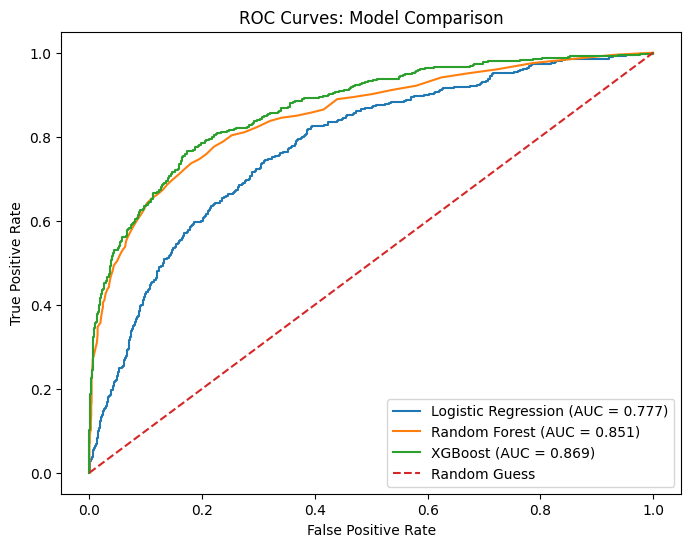

In [12]:
# ROC CURVES FOR ALL MODELS

plt.figure(figsize=(8, 6))

for name, model_obj in models.items():
    y_prob = model_obj.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Model Comparison")
plt.legend()
plt.show()

In [13]:
# FEATURE NAMES AFTER PREPROCESSING

fitted_preprocessor = random_forest_model.named_steps['preprocessor']

ohe = fitted_preprocessor.named_transformers_['cat']
encoded_cat_cols = ohe.get_feature_names_out(categorical_cols)

feature_names = numeric_cols + list(encoded_cat_cols)

print("Number of feature names:", len(feature_names))

Number of feature names: 11



Random Forest Feature Importances:
             feature  importance
1                age    0.248080
3            balance    0.142801
7   estimated_salary    0.136935
0       credit_score    0.134712
4    products_number    0.132607
2             tenure    0.080375
6      active_member    0.036671
8    country_Germany    0.033974
10       gender_Male    0.020489
5        credit_card    0.018779


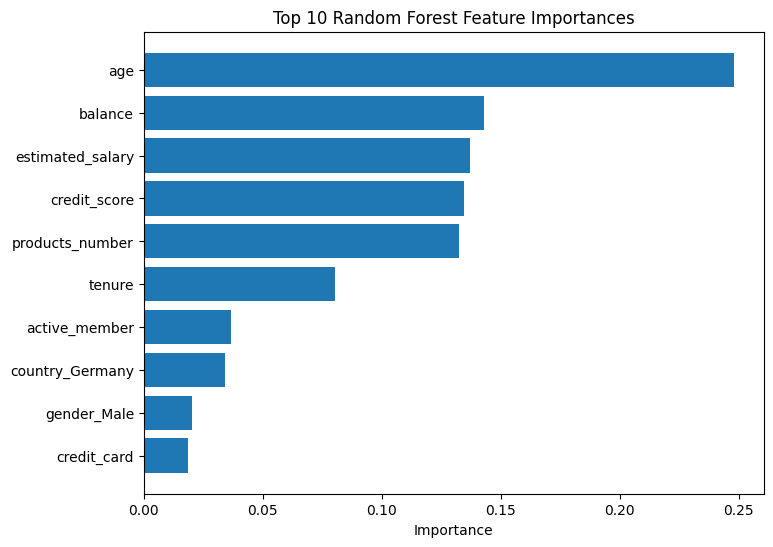

In [14]:
# RANDOM FOREST FEATURE IMPORTANCE

rf_importances = random_forest_model.named_steps['classifier'].feature_importances_

rf_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_importances
}).sort_values(by='importance', ascending=False)

print("\nRandom Forest Feature Importances:")
print(rf_importance_df.head(10))

plt.figure(figsize=(8, 6))
plt.barh(rf_importance_df.head(10)['feature'], rf_importance_df.head(10)['importance'])
plt.xlabel("Importance")
plt.title("Top 10 Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()


XGBoost Feature Importances:
             feature  importance
4    products_number    0.237498
6      active_member    0.221763
1                age    0.196106
8    country_Germany    0.116487
10       gender_Male    0.057414
3            balance    0.050040
9      country_Spain    0.032054
0       credit_score    0.026907
7   estimated_salary    0.024117
2             tenure    0.023808


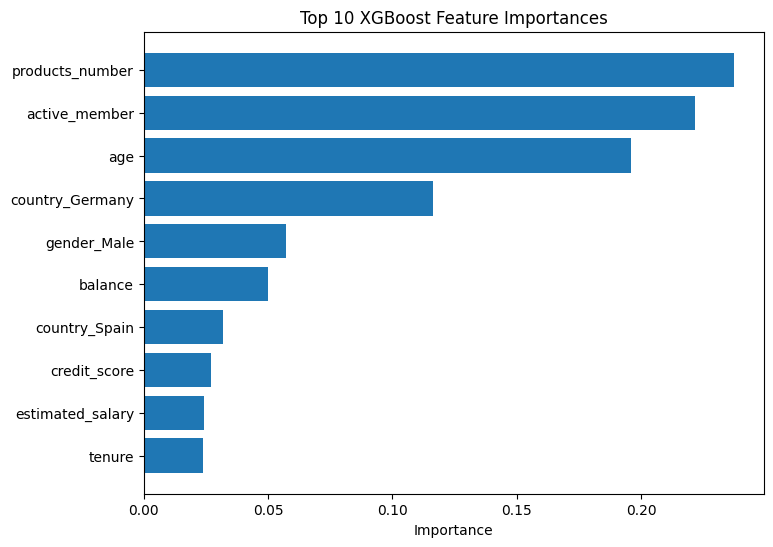

In [15]:
# XGBOOST FEATURE IMPORTANCE

xgb_importances = xgboost_model.named_steps['classifier'].feature_importances_

xgb_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_importances
}).sort_values(by='importance', ascending=False)

print("\nXGBoost Feature Importances:")
print(xgb_importance_df.head(10))

plt.figure(figsize=(8, 6))
plt.barh(xgb_importance_df.head(10)['feature'], xgb_importance_df.head(10)['importance'])
plt.xlabel("Importance")
plt.title("Top 10 XGBoost Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [16]:
import joblib
joblib.dump(xgboost_model, r"C:\Users\rahar\Desktop\Spring 2026\DATA622\Project\churnguard-data622\models\xgboost_model.pkl")

['C:\\Users\\rahar\\Desktop\\Spring 2026\\DATA622\\Project\\churnguard-data622\\models\\xgboost_model.pkl']